# LIBRARIES

In [51]:
import random
import heapq
import itertools
import numpy as np
from scipy.interpolate import interp1d
from scipy import stats
import matplotlib.pyplot as plt
import math

# CLASSES

## MEASURE

In [52]:
class Measure:
    def __init__(self, num_servers: int):
        # Dati discreti
        self.total_arrivals = 0
        self.transmitted_packets = 0
        self.dropped_packets = 0
        self.cumulative_system_delay = 0.0   # Somma dei tempi totali nel sistema (T)
        self.cumulative_waiting_delay = 0.0  # Somma dei soli tempi in coda (W)
        self.packets_that_waited = 0         # Quanti pacchetti hanno effettivamente fatto la fila
        self.delay_list = []                 # Per calcolare la PDF/distribuzione dei ritardi
        
        # Dati continui (Aree per il calcolo delle medie temporali)
        self.area_system = 0.0               # Area per il numero medio di pacchetti nel sistema E[N]
        self.area_queue = 0.0                # Area per il numero medio di pacchetti nel buffer E[N_w]
        self.area_servers_busy = [0.0] * num_servers # Area di occupazione per ciascun trasmettitore
        self.last_update_time = 0.0

    def update_time_averages(self, current_time: float, num_in_system: int, num_in_queue: int, servers: list) -> None:
        """Calcola gli integrali temporali a gradini prima che lo stato del sistema cambi."""
        time_delta = current_time - self.last_update_time
        if time_delta > 0:
            self.area_system += time_delta * num_in_system
            self.area_queue += time_delta * num_in_queue
            for i, s in enumerate(servers):
                self.area_servers_busy[i] += time_delta * (1 if s['busy'] else 0)
        self.last_update_time = current_time

    def record_packet_completion(self, system_delay: float, waiting_delay: float) -> None:
        self.transmitted_packets += 1
        self.cumulative_system_delay += system_delay
        self.cumulative_waiting_delay += waiting_delay
        self.delay_list.append(system_delay)
        if waiting_delay > 0:
            self.packets_that_waited += 1

## PACKET

In [53]:
class Packet:
    def __init__(self, arrival_time: float):
        self.arrival_time = arrival_time
        self.service_start_time = None  # Fondamentale per calcolare il puro tempo di attesa

## ROUTER LINK 

In [54]:
class RouterLink:
    def __init__(self, num_servers: int, lambda_rate: float, mu_rate: float, K: float = float('inf')):
        self.num_servers = num_servers
        self.lambda_rate = lambda_rate
        self.mu_rate = mu_rate
        self.K = K  # Dimensione massima del buffer di coda (K=inf nella baseline del Task 1)
        
        self.queue = []
        # Struttura flessibile per supportare un numero arbitrario di canali di trasmissione
        self.servers = [{'id': i, 'busy': False, 'current_packet': None} for i in range(num_servers)]
        self.stats = Measure(num_servers)

## MULTI QUEUE ROUTER JSQ

In [55]:
class MultiQueueRouterJSQ:
    """Simulatore a Oggetti Dinamico per un Router con N Code Separate integrato con Measure"""
    
    def __init__(self, lambda_rate, mu_rate, num_servers, K_per_queue, seed=42):
        self.lambda_rate = lambda_rate
        self.mu_rate = mu_rate
        self.num_servers = num_servers
        self.K = K_per_queue
        
        # Inizializziamo il tuo oggetto Measure formale!
        self.stats = Measure(num_servers=num_servers)
        random.seed(seed)
        
    def run(self, packets_to_complete):
        time_now = 0.0
        
        # Stati dei server adattati per essere compatibili con Measure [{'busy': bool}]
        server_state = [{'busy': False} for _ in range(self.num_servers)]
        server_deps = [float('inf')] * self.num_servers
        
        # Struttura per tracciare i tempi di ogni pacchetto attualmente in servizio
        server_current_packet = [{'arrival_time': 0.0, 'waiting_delay': 0.0} for _ in range(self.num_servers)]
        
        q_lens = [0] * self.num_servers
        q_arrivals = [[] for _ in range(self.num_servers)]
        
        t_next_arrival = random.expovariate(self.lambda_rate)
        completed_packets = 0
        
        while completed_packets < packets_to_complete:
            min_dep_time = min(server_deps)
            t_event = min(t_next_arrival, min_dep_time)
            
            # --- CHIAMATA A MEASURE: PRIMA DI CAMBIARE LO STATO ---
            num_in_queue = sum(q_lens)
            num_in_system = num_in_queue + sum(1 for s in server_state if s['busy'])
            self.stats.update_time_averages(t_event, num_in_system, num_in_queue, server_state)
            
            time_now = t_event # Aggiorniamo l'orologio interno
            
            if t_event == t_next_arrival: # EVENTO ARRIVO
                self.stats.total_arrivals += 1
                t_next_arrival = time_now + random.expovariate(self.lambda_rate)
                
                # Cerca server liberi
                free_servers = [i for i in range(self.num_servers) if not server_state[i]['busy']]
                
                if free_servers:
                    chosen_idx = random.choice(free_servers) 
                    server_state[chosen_idx]['busy'] = True
                    server_deps[chosen_idx] = time_now + random.expovariate(self.mu_rate)
                    # Va diretto in servizio, ritardo in coda = 0
                    server_current_packet[chosen_idx] = {'arrival_time': time_now, 'waiting_delay': 0.0}
                else:
                    # Routing JSQ
                    min_q = min(q_lens)
                    if min_q < self.K:
                        candidates = [i for i in range(self.num_servers) if q_lens[i] == min_q]
                        chosen_idx = random.choice(candidates)
                        q_lens[chosen_idx] += 1
                        q_arrivals[chosen_idx].append(time_now)
                    else:
                        self.stats.dropped_packets += 1 # Drop
                        
            else: # EVENTO PARTENZA
                departing_idx = server_deps.index(t_event)
                completed_packets += 1
                
                # --- CHIAMATA A MEASURE: REGISTRAZIONE PACCHETTO COMPLETO ---
                arr_time = server_current_packet[departing_idx]['arrival_time']
                wait_delay = server_current_packet[departing_idx]['waiting_delay']
                sys_delay = time_now - arr_time
                self.stats.record_packet_completion(system_delay=sys_delay, waiting_delay=wait_delay)
                
                # Svuotiamo la coda del server
                if q_lens[departing_idx] > 0:
                    q_lens[departing_idx] -= 1
                    next_arr_time = q_arrivals[departing_idx].pop(0)
                    
                    # Calcoliamo quanto ha aspettato in coda prima di entrare in servizio
                    new_wait_delay = time_now - next_arr_time 
                    server_current_packet[departing_idx] = {'arrival_time': next_arr_time, 'waiting_delay': new_wait_delay}
                    server_deps[departing_idx] = time_now + random.expovariate(self.mu_rate)
                else:
                    server_state[departing_idx]['busy'] = False
                    server_deps[departing_idx] = float('inf')
                    
        return self.stats, time_now


# FUNCTIONS

## PACKET ARRIVAL

In [56]:
def packet_arrival(time, FES, router, event_counter):
    # 1. Schedulazione del prossimo arrivo di un pacchetto (Processo di Poisson)
    inter_arrival = random.expovariate(router.lambda_rate)
    heapq.heappush(FES, (time + inter_arrival, next(event_counter), 'packet_arrival', router, event_counter))
    
    # 2. Calcolo dello stato attuale e aggiornamento delle aree statistiche
    num_in_queue = len(router.queue)
    num_in_system = num_in_queue + sum(1 for s in router.servers if s['busy'])
    router.stats.update_time_averages(time, num_in_system, num_in_queue, router.servers)
    
    router.stats.total_arrivals += 1
    packet = Packet(time)
    
    # 3. Allocazione risorsa: cerchiamo il primo trasmettitore libero
    idle_server = next((s for s in router.servers if not s['busy']), None)
    
    if idle_server:
        # Il server è libero: la trasmissione inizia istantaneamente (nessun ritardo di coda)
        idle_server['busy'] = True
        idle_server['current_packet'] = packet
        packet.service_start_time = time
        
        # Scheduliamo la fine della trasmissione (Tempo di servizio esponenziale)
        T_tx = random.expovariate(router.mu_rate)
        heapq.heappush(FES, (time + T_tx, next(event_counter), 'transmission_departure', router, idle_server['id'], packet, event_counter))
    else:
        # Tutti i server sono occupati: proviamo a mettere il pacchetto nel buffer
        if len(router.queue) < router.K:
            router.queue.append(packet)
        else:
            # Buffer pieno: pacchetto scartato (Drop)
            router.stats.dropped_packets += 1

## TRANSMISSION DEPARTURE

In [57]:
def transmission_departure(time, FES, router, server_id, packet, event_counter):
    # 1. Calcolo dello stato attuale e aggiornamento delle aree statistiche
    num_in_queue = len(router.queue)
    num_in_system = num_in_queue + sum(1 for s in router.servers if s['busy'])
    router.stats.update_time_averages(time, num_in_system, num_in_queue, router.servers)
    
    # 2. Identifichiamo e liberiamo il server che ha completato la trasmissione
    server = next(s for s in router.servers if s['id'] == server_id)
    server['busy'] = False
    server['current_packet'] = None
    
    # 3. Registrazione dei ritardi del pacchetto appena uscito
    system_delay = time - packet.arrival_time
    waiting_delay = packet.service_start_time - packet.arrival_time
    router.stats.record_packet_completion(system_delay, waiting_delay)
    
    # 4. Politica di servizio (FIFO): se ci sono pacchetti in coda, il server li serve subito
    if len(router.queue) > 0:
        next_packet = router.queue.pop(0)
        next_packet.service_start_time = time
        
        server['busy'] = True
        server['current_packet'] = next_packet
        
        T_tx = random.expovariate(router.mu_rate)
        heapq.heappush(FES, (time + T_tx, next(event_counter), 'transmission_departure', router, server['id'], next_packet, event_counter))

## RUN SIM ROUTER

In [58]:
def run_sim_router(tasks_to_complete, lambda_rate, mu_rate, num_servers=1, K=float('inf'), seed=42):
    random.seed(seed)
    event_counter = itertools.count() 
    FES = []
    
    # Inizializzazione del nostro link del router
    router = RouterLink(num_servers=num_servers, lambda_rate=lambda_rate, mu_rate=mu_rate, K=K)
    
    # Innesco del sistema (primo pacchetto a t=0)
    heapq.heappush(FES, (0.0, next(event_counter), 'packet_arrival', router, event_counter))
    
    # Liste per il campionamento continuo delle traiettorie
    time_points = [0.0]
    queue_lengths = [0]
    system_lengths = [0]
    
    current_time = 0.0
    
    # Il ciclo gira finché non abbiamo trasmesso il numero di pacchetti richiesti
    while router.stats.transmitted_packets < tasks_to_complete and len(FES) > 0:
        event_time, _, event_type, *args = heapq.heappop(FES)
        current_time = event_time
        
        if event_type == 'packet_arrival':
            packet_arrival(current_time, FES, args[0], args[1])
        elif event_type == 'transmission_departure':
            transmission_departure(current_time, FES, args[0], args[1], args[2], args[3]) #arg
        # args[0] = router, args[1] = server_id, args[2] = packet, args[3] = event_counter
        # Registrazione dello stato istantaneo per le medie di ensemble
        busy_count = sum(1 for s in router.servers if s['busy'])
        time_points.append(current_time)
        queue_lengths.append(len(router.queue))
        system_lengths.append(len(router.queue) + busy_count)
        
    # Forza l'ultimo aggiornamento delle aree alla fine della simulazione
    busy_count = sum(1 for s in router.servers if s['busy'])
    router.stats.update_time_averages(current_time, len(router.queue) + busy_count, len(router.queue), router.servers)
        
    return router.stats, time_points, queue_lengths, system_lengths

## RUN MULTIPLE SIMULATIONS

In [59]:
def run_multiple_sims_router(num_runs, packets_to_complete, time_limit, lambda_rate, mu_rate, num_servers=1, K=float('inf')):
    all_delays = np.zeros((num_runs, packets_to_complete))
    
    # Griglia temporale fissa per le metriche continue (es. 10 campioni/s)
    num_samples = int(time_limit * 10) 
    time_grid = np.linspace(0, time_limit, num_samples)
    
    sum_queues = np.zeros(num_samples)
    sum_system = np.zeros(num_samples) # Riaggiunto!
    losses = np.zeros(num_runs)        # Nuovo per il Task 2
    
    for i in range(num_runs):
        stats, t_pts, q_lens, s_lens = run_sim_router(
            tasks_to_complete=packets_to_complete, 
            lambda_rate=lambda_rate, 
            mu_rate=mu_rate, 
            num_servers=num_servers,
            K=K,
            seed=(42+i)
        )
        
        # Salviamo i ritardi e le perdite
        all_delays[i, :] = stats.delay_list[:packets_to_complete]
        losses[i] = stats.dropped_packets / stats.total_arrivals
        
        # Interpolazione a gradini per TUTTE le metriche continue
        f_q = interp1d(t_pts, q_lens, kind='previous', fill_value="extrapolate")
        f_s = interp1d(t_pts, s_lens, kind='previous', fill_value="extrapolate") # Riaggiunto!
        
        sum_queues += f_q(time_grid)
        sum_system += f_s(time_grid) # Riaggiunto!
        
    # Calcolo delle Ensemble Averages
    avg_queue = sum_queues / num_runs
    avg_system = sum_system / num_runs # Riaggiunto!
    avg_delay = np.mean(all_delays, axis=0) 
    avg_loss = np.mean(losses)         # Nuovo per il Task 2
    
    # Ora restituisce 6 valori, mantenendo l'ordine logico
    return time_grid, avg_queue, avg_system, avg_delay, all_delays, avg_loss

## RUN MULTIPLE JSQ GENERIC

In [60]:
def run_multiple_jsq_generic(num_runs, packets_to_complete, lambda_rate, mu_rate, num_servers, K_per_queue):
    all_delays = np.zeros((num_runs, packets_to_complete))
    losses = np.zeros(num_runs)
    avg_queues = np.zeros(num_runs)
    avg_systems = np.zeros(num_runs)
    
    for i in range(num_runs):
        router = MultiQueueRouterJSQ(lambda_rate, mu_rate, num_servers, K_per_queue, seed=42+i)
        
        # Riceviamo stats e il tempo totale di simulazione
        stats, final_time = router.run(packets_to_complete)
        
        all_delays[i, :] = stats.delay_list[:packets_to_complete]
        losses[i] = stats.dropped_packets / stats.total_arrivals if stats.total_arrivals > 0 else 0
        
        # LA MAGIA DI MEASURE: Aree divise per il tempo finale! Nessuna interpolazione necessaria.
        avg_queues[i] = stats.area_queue / final_time
        avg_systems[i] = stats.area_system / final_time
        
    # Ritorniamo le medie su tutte le run
    return np.mean(avg_queues), np.mean(avg_systems), np.mean(all_delays, axis=0), all_delays, np.mean(losses)

## ANALYZE WARMUP

In [61]:
def analyze_warmup(ensemble_delays, max_discard_percent=0.60, k_star=300):
    n = len(ensemble_delays)
    x_bar = np.mean(ensemble_delays)
    x_bar_k_star = np.mean(ensemble_delays[k_star:])
    
    max_k = int(n * max_discard_percent)
    k_values = np.arange(1, max_k + 1)
    
    x_bar_k_list = [np.mean(ensemble_delays[k:]) for k in k_values]
    
    # --- 1° GRAFICO: Media Troncata ---
    plt.figure(figsize=(10, 5))
    plt.plot(k_values, x_bar_k_list, color='purple', linewidth=2, label='Media Troncata ($\overline{X}_k$)')
    plt.axhline(y=x_bar_k_star, color='green', linestyle='--', linewidth=2, 
                label=f'Media a regime ($k^*={k_star}$) = {x_bar_k_star:.3f} s')
    
    plt.title(f"Ricerca del Transitorio: Media Troncata", fontsize=14)
    plt.xlabel("Numero di pacchetti scartati ($k$)", fontsize=12)
    plt.ylabel("Ritardo Medio Troncato [s]", fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.legend()
    plt.tight_layout()
    plt.show()

<>:13: SyntaxWarning: invalid escape sequence '\o'
<>:13: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_4337/449698133.py:13: SyntaxWarning: invalid escape sequence '\o'
  plt.plot(k_values, x_bar_k_list, color='purple', linewidth=2, label='Media Troncata ($\overline{X}_k$)')


## PERFORM STATISTICAL ANALYSIS

In [62]:
# Cella: Funzione di Analisi Statistica aggiornata
def perform_statistical_analysis(all_delays, k_star=300, confidence=0.95):
    data = np.array(all_delays)
    trimmed_data = data[:, k_star:] 
    
    run_means = np.mean(trimmed_data, axis=1)
    n = len(run_means)
    mean_of_means = np.mean(run_means)
    std_err = stats.sem(run_means) 
    
    # LA TUA INTUIZIONE APPLICATA IN CODICE:
    if n >= 30:
        # Usa la Gaussiana (Normale) per n >= 30
        z = stats.norm.ppf((1 + confidence) / 2)
        h = std_err * z
        dist_used = "Gaussiana (Normale)"
    else:
        # Usa Student per campioni piccoli (n < 30)
        t = stats.t.ppf((1 + confidence) / 2, n - 1)
        h = std_err * t
        dist_used = "t di Student"
    
    lower_bound = mean_of_means - h
    upper_bound = mean_of_means + h
    
    print(f"Statistica: N={n} repliche. Applicata distribuzione {dist_used}.")
    return mean_of_means, lower_bound, upper_bound

## COMPUTE THEORETICAL METRICS

In [63]:
def compute_theoretical_metrics(lambda_rate, mu_rate, servers=1, buffer_size=float('inf')):
    """
    Computes exact theoretical metrics for both M/M/c and M/M/c/K queueing systems.
    
    Parameters:
    - lambda_rate: Arrival rate
    - mu_rate: Service rate of a single server
    - servers (c): Number of parallel servers
    - buffer_size (K): Maximum number of packets allowed in the waiting queue
    
    Returns:
    - E_T: Expected delay in the system
    - E_Nw: Expected number of packets in the queue
    - P_loss: Probability of a packet being dropped
    """
    c = servers
    K = buffer_size
    a = lambda_rate / mu_rate
    rho = a / c
    
    # ==========================================
    # SCENARIO 1: Buffer Infinito (Modello M/M/c)
    # ==========================================
    if K == float('inf'):
        if rho >= 1.0:
            return float('inf'), float('inf'), 0.0
            
        sum_c = sum((a**n) / math.factorial(n) for n in range(c))
        term_c = (a**c) / (math.factorial(c) * (1 - rho))
        P0 = 1.0 / (sum_c + term_c)
        
        P_queue = P0 * term_c
        E_Nw = P_queue * (rho / (1 - rho))
        E_T = (E_Nw / lambda_rate) + (1.0 / mu_rate)
        
        return E_T, E_Nw, 0.0

    # ==========================================
    # SCENARIO 2: Buffer Finito (Modello M/M/c/K)
    # ==========================================
    N_max = K + c # Maximum capacity (queue + servers)
    
    # 1. Calculate P0 (Probability of empty system)
    sum_c = sum((a**n) / math.factorial(n) for n in range(c + 1))
    if abs(rho - 1.0) < 1e-6:
        sum_k = ((a**c) / math.factorial(c)) * K
    else:
        sum_k = ((a**c) / math.factorial(c)) * rho * (1 - rho**K) / (1 - rho)
        
    P0 = 1.0 / (sum_c + sum_k)
    
    # 2. Calculate P_loss (Probability system is completely full)
    P_loss = P0 * (a**N_max) / (math.factorial(c) * (c**K))
    
    # 3. Calculate E[Nw] (Expected packets in queue)
    if abs(rho - 1.0) < 1e-6:
        E_Nw = P0 * (a**c / math.factorial(c)) * (K * (K + 1) / 2)
    else:
        term1 = P0 * (a**c * rho) / (math.factorial(c) * (1 - rho)**2)
        term2 = 1 - rho**K - K * (rho**K) * (1 - rho)
        E_Nw = term1 * term2
        
    # 4. Calculate E[T] using Effective Little's Law
    lambda_eff = lambda_rate * (1 - P_loss)
    if lambda_eff > 0:
        E_T = (E_Nw / lambda_eff) + (1.0 / mu_rate)
    else:
        E_T = 0.0
        
    return E_T, E_Nw, P_loss

## PLOTS

### PLOT AVG CURVE

In [64]:
def plot_avg_delay(avg_delay, lambda_rate, mu_rate, zoom_packets=None):
    plt.figure(figsize=(10, 4))
    packet_indices = range(1, len(avg_delay) + 1)
    
    plt.plot(packet_indices, avg_delay, color='red', linewidth=1.5, label='Simulazione (Media Ensemble)')
    
    if lambda_rate < mu_rate:
        # FORMULA TEORICA M/M/1: E[T] = 1 / (mu - lambda)
        delay_teorico = 1.0 / (mu_rate - lambda_rate)
        plt.axhline(y=delay_teorico, color='black', linestyle='--', linewidth=2,
                    label=f'Teorico a Regime ({delay_teorico:.3f} s)')
        
    plt.title("Ritardo Medio per Pacchetto (M/M/1)")
    plt.xlabel("Indice Pacchetto")
    plt.ylabel("Ritardo Medio [s]")
    if zoom_packets is not None:
        plt.xlim(0, zoom_packets)
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.legend(loc="lower right")
    plt.show()

### PLOT AVG QUEUE

In [65]:
def plot_avg_queue(time_grid, avg_queue, lambda_rate, mu_rate, zoom_time=None):
    plt.figure(figsize=(10, 4))
    plt.plot(time_grid, avg_queue, color='blue', linewidth=1.5, label='Simulazione (Evoluzione Coda)')
    
    if lambda_rate < mu_rate:
        # FORMULA TEORICA M/M/1: E[N_w] = rho^2 / (1 - rho) dove rho = lambda/mu
        rho = lambda_rate / mu_rate
        queue_teorica = (rho**2) / (1 - rho)
        plt.axhline(y=queue_teorica, color='black', linestyle='--', linewidth=2,
                    label=f'Teorico a Regime E[Nw] ({queue_teorica:.2f} pkt)')

    plt.title("Evoluzione nel Tempo dei Pacchetti in Attesa nel Buffer (M/M/1)")
    plt.xlabel("Tempo [s]")
    plt.ylabel("Numero Medio in Coda")
    if zoom_time is not None:
        plt.xlim(0, zoom_time)
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.legend(loc="lower right")
    plt.show()

### PLOT LOSS CURVE

In [66]:
def plot_loss_curve(loads, losses, errors=None, K=float('inf'), num_servers=1):
    plt.figure(figsize=(10, 5))
    
    # Curva della Simulazione (con eventuali barre di errore)
    if errors is not None and len(errors) > 0:
        plt.errorbar(loads, losses, yerr=errors, fmt='-^', color='purple', capsize=5, label='Simulazione', markersize=8)
    else:
        plt.plot(loads, losses, '-^', color='purple', label='Simulazione', markersize=8)
    
    # CURVA TEORICA (M/M/c/K)
    theoretical_losses = []
    # N è la capacità totale del sistema (Buffer K + i server)
    N = K + num_servers 
    
    for rho in loads:
        if K == float('inf'):
            theoretical_losses.append(0.0)
        else:
            # Formula M/M/1/K: P_loss = (1 - rho) * rho^N / (1 - rho^(N+1))
            if abs(rho - 1.0) < 1e-6:
                p_loss = 1.0 / (N + 1)
            else:
                p_loss = ((1 - rho) * (rho**N)) / (1 - (rho**(N+1)))
            theoretical_losses.append(p_loss)
            
    plt.plot(loads, theoretical_losses, color='black', linestyle='--', linewidth=2, label=f'Teorico a Regime (K={K})')

    plt.title("Probabilità di Perdita (Loss Probability) vs Carico")
    plt.xlabel("Carico Offerto ($\lambda / \mu$)")
    plt.ylabel("Probabilità di Perdita (P_loss)")
    
    # Se il buffer è infinito, mettiamo un margine Y stretto per far vedere che è 0
    if K == float('inf'):
        plt.ylim(-0.01, 0.05)
        
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.legend()
    plt.show()

<>:29: SyntaxWarning: invalid escape sequence '\l'
<>:29: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_4337/2638911856.py:29: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel("Carico Offerto ($\lambda / \mu$)")


### PLOT DELAY DISTRIBUTION

In [67]:
def plot_delay_distribution(all_delays, lambda_rate, mu_rate, k_star=300, bins=50):
    # Rimuoviamo il warm-up e appiattiamo tutto in un unico grande vettore
    valid_delays = all_delays[:, k_star:].flatten()
    
    plt.figure(figsize=(10, 5))
    
    # Istogramma della simulazione (densità di probabilità)
    plt.hist(valid_delays, bins=bins, density=True, color='skyblue', edgecolor='black', alpha=0.7, label='Simulazione (Istogramma)')
    
    # CURVA TEORICA M/M/1: f(t) = (mu - lambda) * exp(-(mu - lambda) * t)
    if lambda_rate < mu_rate:
        t_values = np.linspace(0, max(valid_delays), 200)
        pdf_teorica = (mu_rate - lambda_rate) * np.exp(-(mu_rate - lambda_rate) * t_values)
        plt.plot(t_values, pdf_teorica, color='black', linestyle='--', linewidth=2, label='Teorico: Esponenziale')

    plt.title(f"Distribuzione del Ritardo nel Sistema (Rho = {lambda_rate/mu_rate:.2f})")
    plt.xlabel("Ritardo [s]")
    plt.ylabel("Densità di Probabilità f(t)")
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.legend()
    plt.show()

# TASK 1

 FASE 1: SIMULAZIONE GREZZA (FORZA BRUTA SUI CARICHI ALTI) 
Simulazione in corso: Rho = 0.20 | 15 Run | 2000 Pkt...


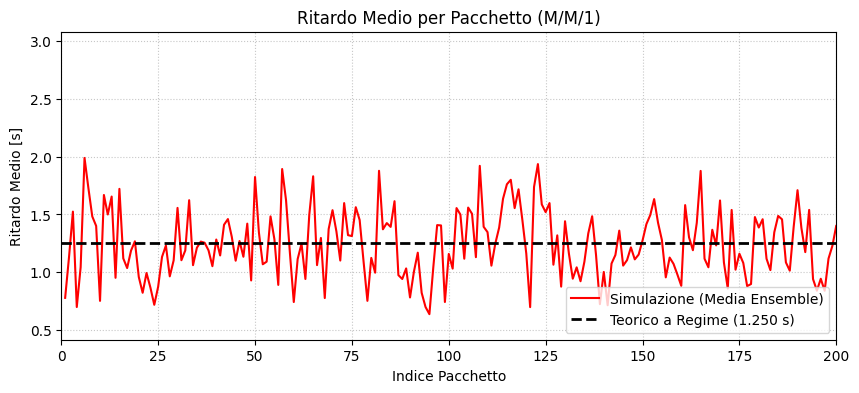

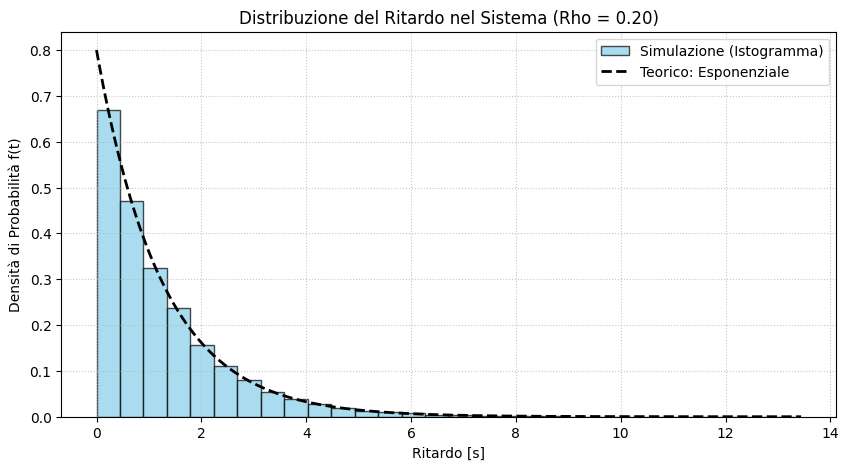

Simulazione in corso: Rho = 0.40 | 15 Run | 2000 Pkt...


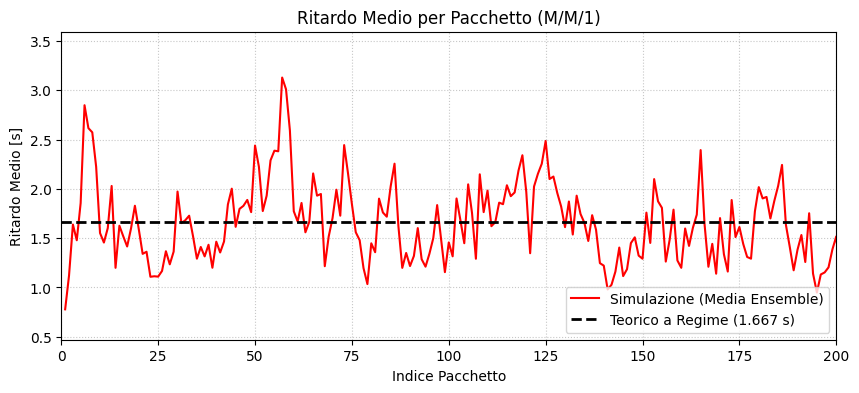

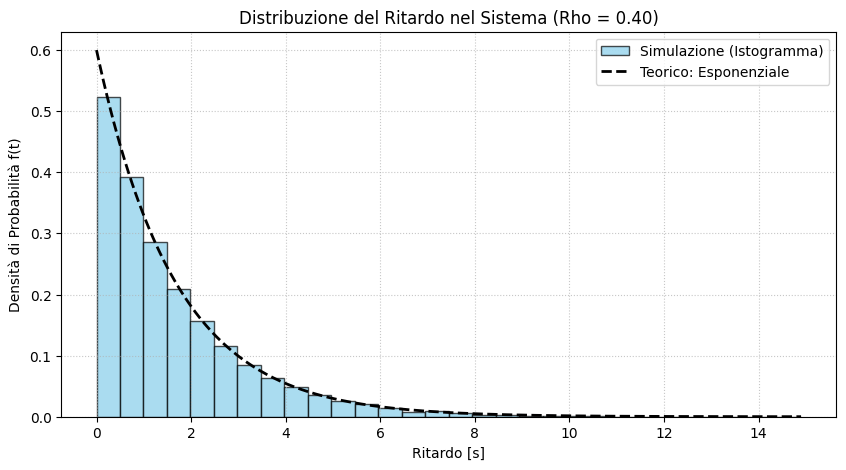

Simulazione in corso: Rho = 0.60 | 15 Run | 2000 Pkt...


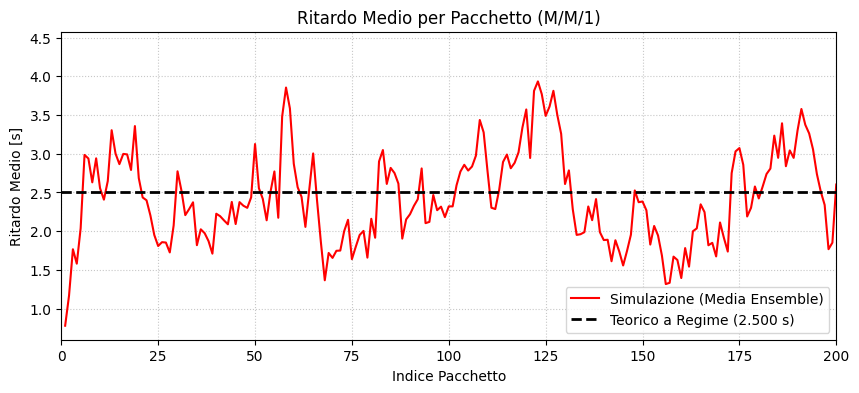

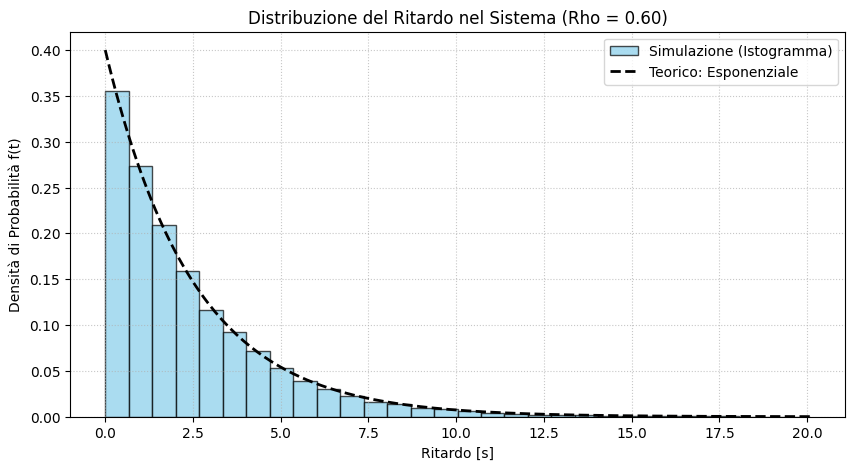

Simulazione in corso: Rho = 0.80 | 50 Run | 8000 Pkt...


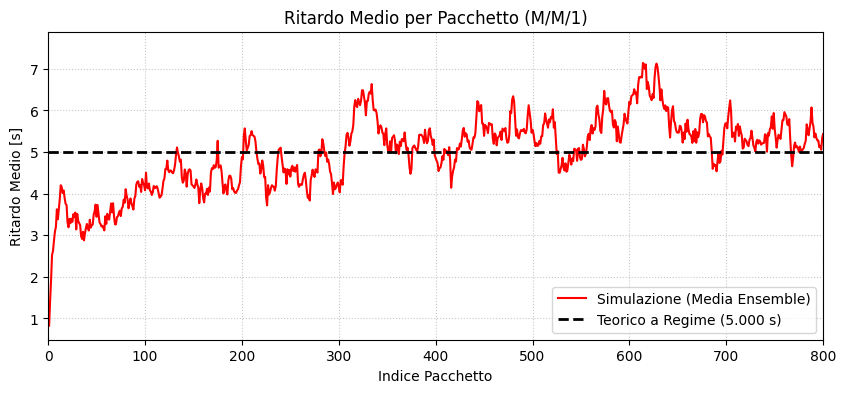

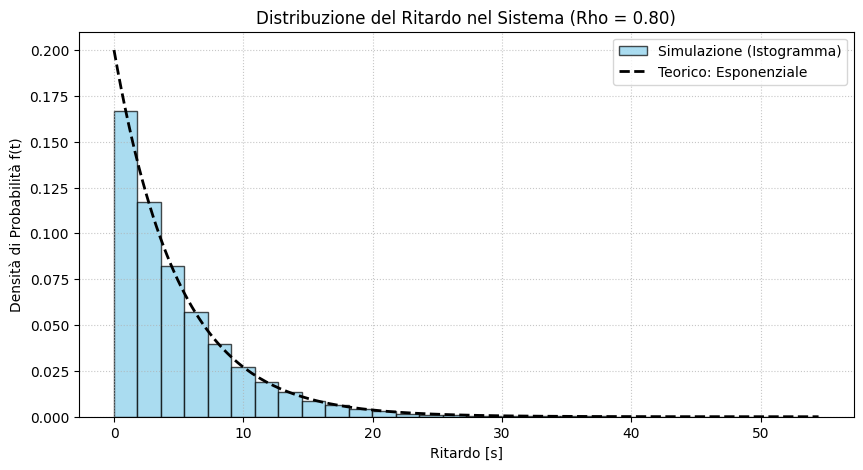

Simulazione in corso: Rho = 0.90 | 80 Run | 25000 Pkt...


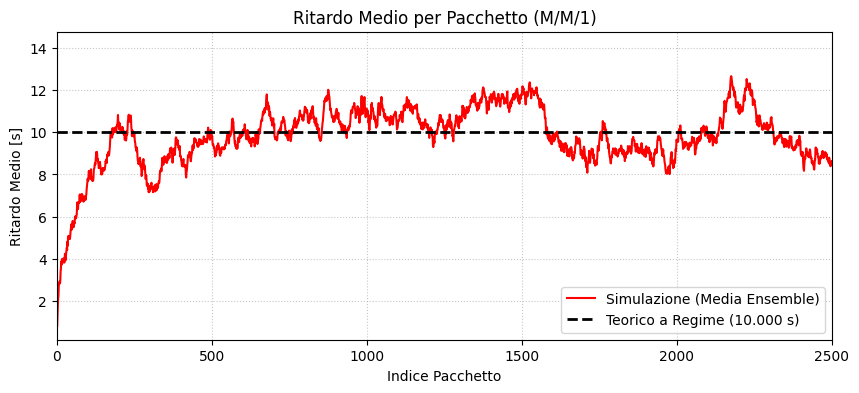

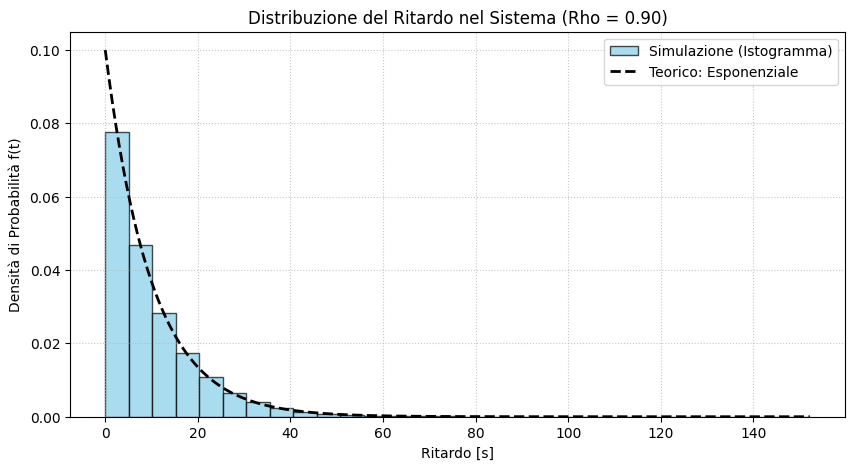


Simulazioni completate. Dati salvati in 'raw_results'.


In [68]:
# --- FASE 1 POTENZIATA: RACCOLTA DATI GREZZI (SMART RUNS) ---
MU_RATE = 1.0
lambdas_to_test = [0.2, 0.4, 0.6, 0.8, 0.9]

raw_results = {}

print("="*60)
print(" FASE 1: SIMULAZIONE GREZZA (FORZA BRUTA SUI CARICHI ALTI) ")
print("="*60)

for lmb in lambdas_to_test:
    rho = lmb / MU_RATE
    
    # 1. Regoliamo i PACCHETTI: pochi per carichi bassi, tantissimi per carichi alti
    if rho < 0.7:
        packets_totali = 2000
        run_dinamiche = 15     # Poca varianza, bastano poche run
    elif rho == 0.8:
        packets_totali = 8000  # Transitorio lungo
        run_dinamiche = 50     # Alta varianza, servono molte run!
    else: # rho == 0.9
        packets_totali = 25000 # Transitorio lunghissimo
        run_dinamiche = 80     # Varianza estrema, serve un esercito di run!
        
    safe_time_limit = (packets_totali / lmb) * 1.5 
    
    print(f"Simulazione in corso: Rho = {rho:.2f} | {run_dinamiche} Run | {packets_totali} Pkt...")
    
    # Lanciamo il simulatore con i parametri "pompati"
    time_grid, avg_queue, avg_system, avg_delay, all_delays, _ = run_multiple_sims_router(
        num_runs=run_dinamiche, 
        packets_to_complete=packets_totali, 
        time_limit=safe_time_limit, 
        lambda_rate=lmb, 
        mu_rate=MU_RATE
    )
    
    raw_results[lmb] = {
        'avg_queue': avg_queue,
        'avg_delay': avg_delay,
        'all_delays': all_delays,
        'packets': packets_totali
    }

    plot_avg_delay(avg_delay, lmb, MU_RATE, zoom_packets=packets_totali//10)
    plot_delay_distribution(all_delays, lmb, MU_RATE, k_star=0, bins=30)

print("\nSimulazioni completate. Dati salvati in 'raw_results'.")

 ANALISI DEL TRANSITORIO (WARM-UP) PER OGNI SCENARIO 

▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼
  SCENARIO: Lambda = 0.2 (Rho = 0.20)  |  K* applicato = 5
▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲


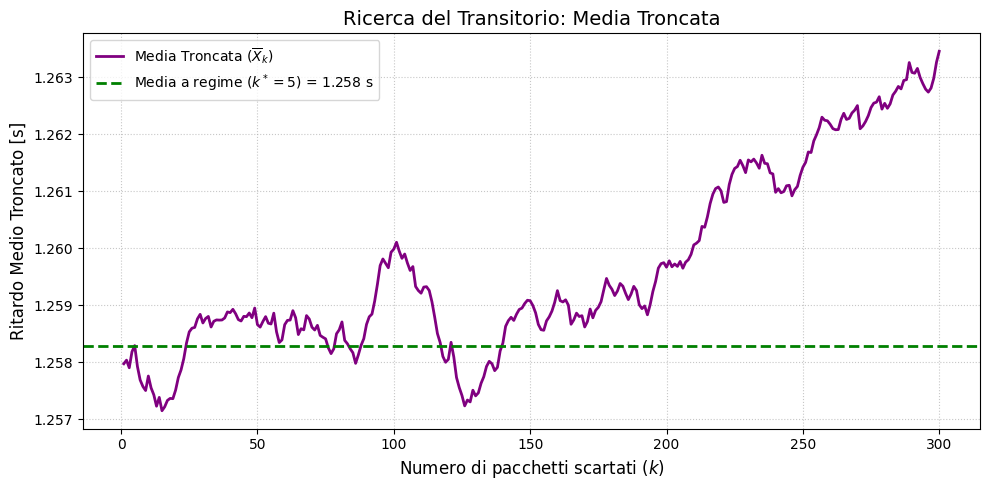


▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼
  SCENARIO: Lambda = 0.4 (Rho = 0.40)  |  K* applicato = 5
▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲


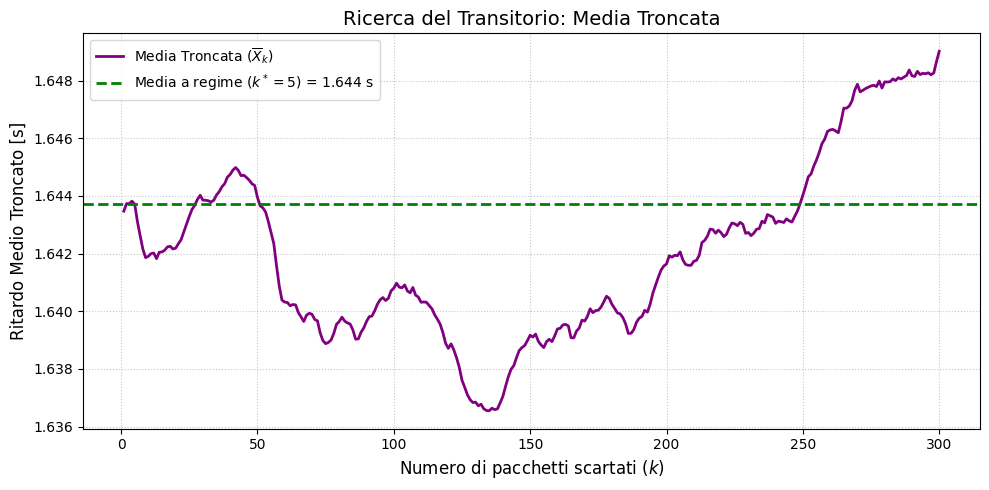


▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼
  SCENARIO: Lambda = 0.6 (Rho = 0.60)  |  K* applicato = 10
▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲


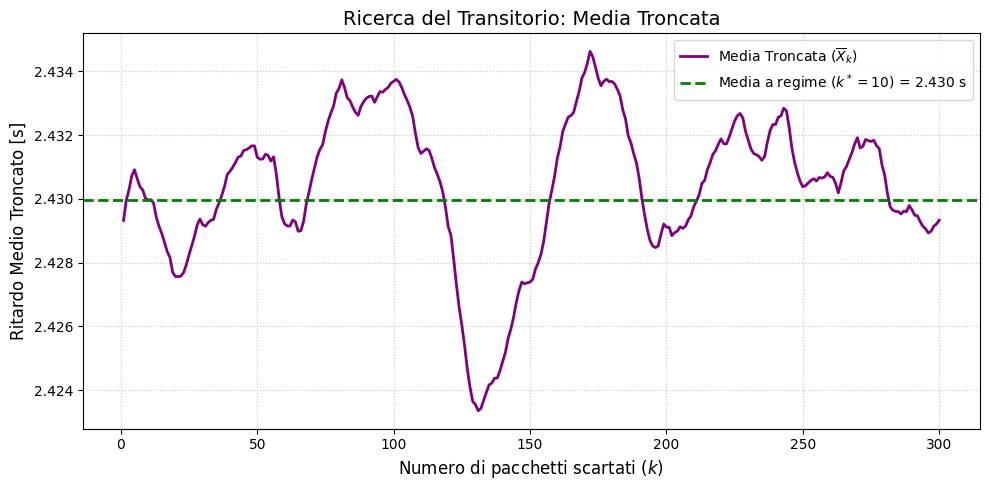


▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼
  SCENARIO: Lambda = 0.8 (Rho = 0.80)  |  K* applicato = 500
▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲


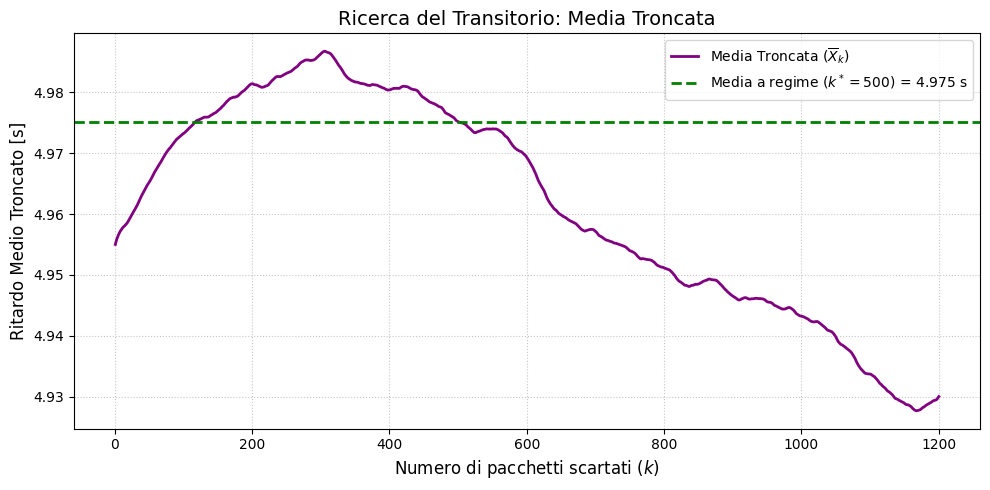


▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼
  SCENARIO: Lambda = 0.9 (Rho = 0.90)  |  K* applicato = 1000
▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲


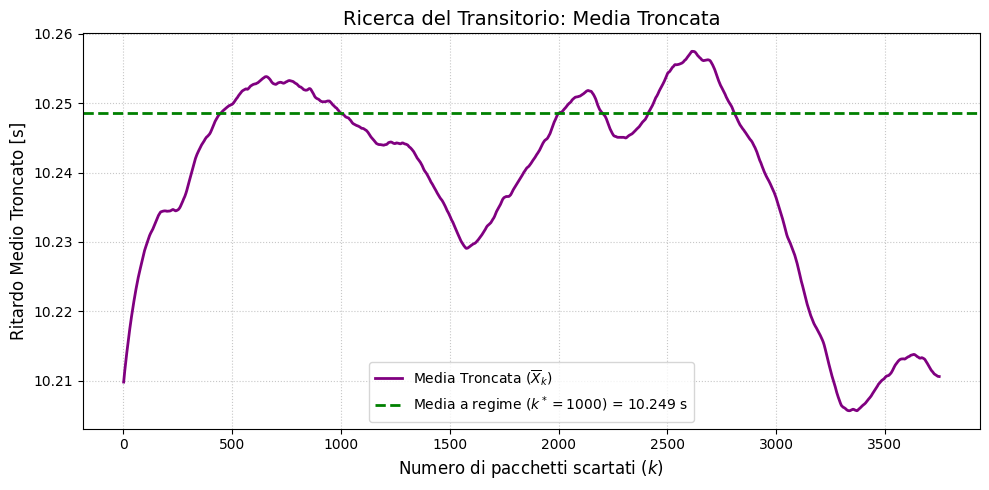

In [69]:
# --- FASE 2: DASHBOARD DI VERIFICA DEI WARM-UP ---

# I tuoi k_star scelti euristica per ciascun Lambda
k_stars_test = [5, 5, 10, 500, 1000] 

print("="*60)
print(" ANALISI DEL TRANSITORIO (WARM-UP) PER OGNI SCENARIO ")
print("="*60)

# Iteriamo abbinando i lambda ai k_star che hai scelto
# (Usiamo zip così se le liste hanno lunghezze diverse non va in errore)
for lmb, k_star in zip(lambdas_to_test, k_stars_test):
    rho = lmb / MU_RATE
    
    # Intestazione grafica per separare bene l'output nel Notebook
    print(f"\n" + "▼"*60)
    print(f"  SCENARIO: Lambda = {lmb} (Rho = {rho:.2f})  |  K* applicato = {k_star}")
    print("▲"*60)
    
    # Estraiamo i dati grezzi corretti
    dati_grezzi = raw_results[lmb]
    
    # ATTENZIONE: Passiamo 'avg_delay' (il vettore 1D della media di ensemble), 
    # NON 'all_delays' (che è la matrice 2D)
    ritardo_medio_ensemble = dati_grezzi['avg_delay']
    
    # Chiamiamo la funzione di plot
    analyze_warmup(
        ensemble_delays=ritardo_medio_ensemble, 
        max_discard_percent=0.15, 
        k_star=k_star
    )

In [70]:
# --- FASE 3: ELABORAZIONE FINALE CON I TUOI K_STAR ---

# Inserisci qui dentro i 5 numeri che hai scoperto usando la Cella 10!


loads = []
mean_delays = []
delay_errors = []
mean_queues = []
losses = []

print("="*50)
print(" FASE 3: TAGLIO DEL WARM-UP E STATISTICA FINALE ")
print("="*50)

for i, lmb in enumerate(lambdas_to_test):
    rho = lmb / MU_RATE
    loads.append(rho)
    
    k_star = k_stars_test[i]
    dati = raw_results[lmb]
    
    print(f"Applicazione K*={k_star} per Lambda={lmb}...")
    
    # 1. Ritardo e Confidenza (usando la funzione statistica)
    mean_d, lb_d, ub_d = perform_statistical_analysis(dati['all_delays'], k_star=k_star, confidence=0.95)
    
    mean_delays.append(mean_d)
    delay_errors.append(mean_d - lb_d)
    
    # 2. Coda Media (usando la proporzione temporale)
    warmup_time_ratio = k_star / dati['packets']
    warmup_idx = int(len(dati['avg_queue']) * warmup_time_ratio)
    mean_queues.append(np.mean(dati['avg_queue'][warmup_idx:]))
    
    

print("\nElaborazione completata. Generazione grafici prestazionali in corso...")



 FASE 3: TAGLIO DEL WARM-UP E STATISTICA FINALE 
Applicazione K*=5 per Lambda=0.2...
Statistica: N=15 repliche. Applicata distribuzione t di Student.
Applicazione K*=5 per Lambda=0.4...
Statistica: N=15 repliche. Applicata distribuzione t di Student.
Applicazione K*=10 per Lambda=0.6...
Statistica: N=15 repliche. Applicata distribuzione t di Student.
Applicazione K*=500 per Lambda=0.8...
Statistica: N=50 repliche. Applicata distribuzione Gaussiana (Normale).
Applicazione K*=1000 per Lambda=0.9...
Statistica: N=80 repliche. Applicata distribuzione Gaussiana (Normale).

Elaborazione completata. Generazione grafici prestazionali in corso...


In [71]:
# Generiamo un asse X continuo (100 punti) per tracciare le curve analitiche in modo fluido
rho_smooth = np.linspace(min(loads), max(loads), 100)
lmb_smooth = rho_smooth * MU_RATE

# Formule Teoriche M/M/1
delay_teorico = 1.0 / (MU_RATE - lmb_smooth)
coda_teorica = (rho_smooth**2) / (1 - rho_smooth)

<>:11: SyntaxWarning: invalid escape sequence '\d'
<>:11: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_4337/1242208429.py:11: SyntaxWarning: invalid escape sequence '\d'
  label='Theory: $E[T] = \dfrac{1}{\mu - \lambda}$')


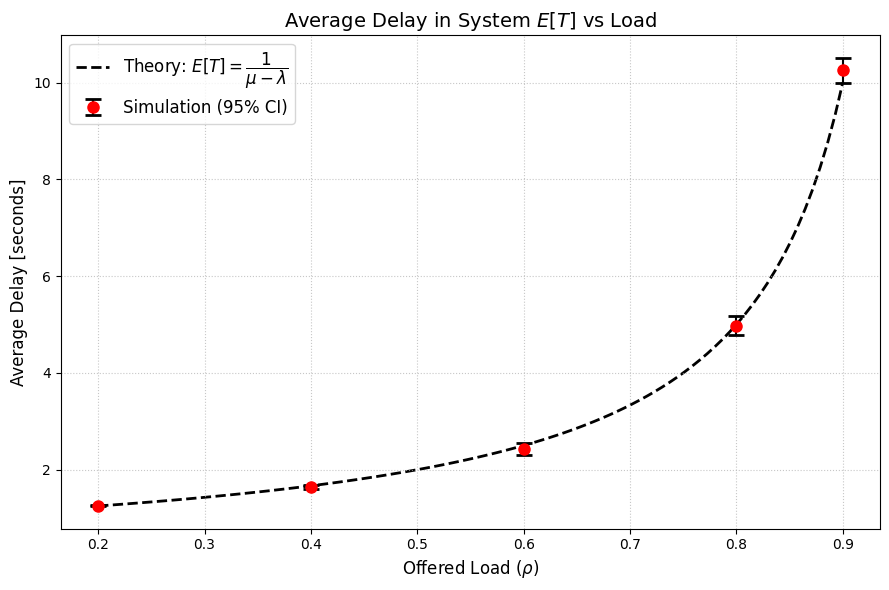

In [72]:
# --- PLOT 1: RITARDO MEDIO CON INTERVALLI DI CONFIDENZA ---
plt.figure(figsize=(9, 6))

# Dati simulati (con IC al 95%)
plt.errorbar(loads, mean_delays, yerr=delay_errors, fmt='o', color='red',
             ecolor='black', capsize=6, capthick=2, markersize=8,
             label='Simulation (95% CI)')

# Curva analitica
plt.plot(rho_smooth, delay_teorico, color='black', linestyle='--', linewidth=2, zorder=0,
         label='Theory: $E[T] = \dfrac{1}{\mu - \lambda}$')

plt.title("Average Delay in System $E[T]$ vs Load", fontsize=14)
plt.xlabel("Offered Load ($\\rho$)", fontsize=12)
plt.ylabel("Average Delay [seconds]", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(fontsize=12)

# Salva l'immagine se ti serve per un PDF, o mostrala nel notebook
plt.tight_layout()
plt.show()

<>:10: SyntaxWarning: invalid escape sequence '\d'
<>:10: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_4337/4292183794.py:10: SyntaxWarning: invalid escape sequence '\d'
  label='Theory: $E[N_w] = \dfrac{\\rho^2}{1 - \\rho}$')


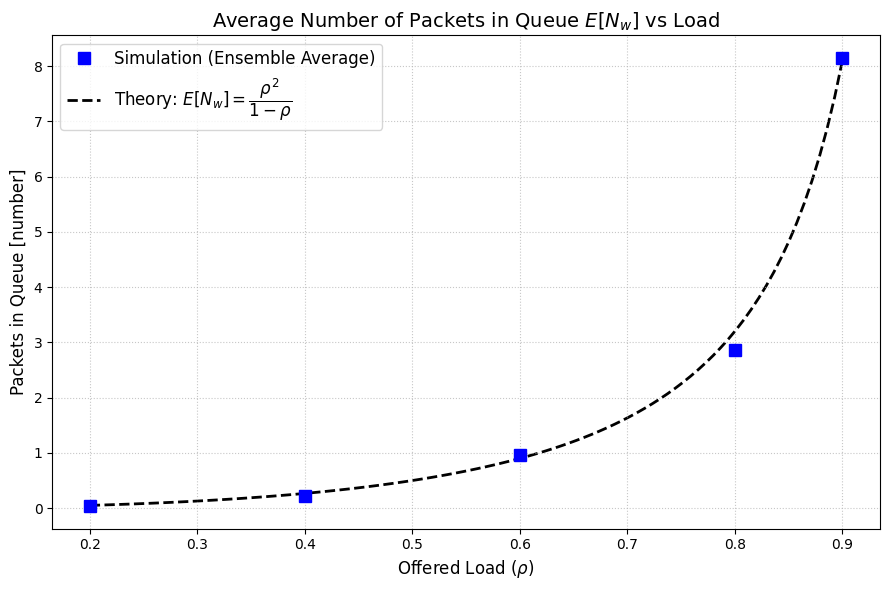

In [73]:
# --- PLOT 2: NUMERO MEDIO DI PACCHETTI IN CODA ---
plt.figure(figsize=(9, 6))

# Dati simulati (Medie di Ensemble troncate)
plt.plot(loads, mean_queues, 's', color='blue', markersize=8, 
         label='Simulation (Ensemble Average)')

# Curva analitica
plt.plot(rho_smooth, coda_teorica, color='black', linestyle='--', linewidth=2, zorder=0,
         label='Theory: $E[N_w] = \dfrac{\\rho^2}{1 - \\rho}$')

plt.title("Average Number of Packets in Queue $E[N_w]$ vs Load", fontsize=14)
plt.xlabel("Offered Load ($\\rho$)", fontsize=12)
plt.ylabel("Packets in Queue [number]", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(fontsize=12)

plt.tight_layout()
plt.show()

# TASK 2

## .a

In [74]:
MU_BASE = 1.0 # Entrambi i sistemi usano server con questa stessa capacità

# Testiamo i carichi spingendo l'M/M/1 fino al suo limite teorico (0.95)
lambdas_comp = [0.2, 0.4, 0.6, 0.8, 0.95]

# Liste per salvare le "Tre Sorelle" delle metriche
delay_1, queue_1, util_1 = [], [], []
delay_2, queue_2, util_2 = [], [], []

In [75]:
print("="*60)
print(" TASK 2(a): CONFRONTO M/M/1 vs M/M/2 (mu=1.0) ")
print("="*60)

for lmb in lambdas_comp:
    # Aumentiamo pesantemente i pacchetti per i carichi critici
    packets_totali = int(2000 + (25000 * (lmb**4)))
    safe_time_limit = (packets_totali / lmb) * 1.5 
    k_star_dinamico = int(packets_totali * 0.20) # Tagliamo il 20% come warm-up
    
    print(f"Simulazione in corso: Lambda = {lmb} ({packets_totali} pacchetti)...")
    
    # ---------------------------------------------------------
    # 1. RUN M/M/1 (Un server)
    # ---------------------------------------------------------
    _, q_1, sys_1, _, all_d_1, _ = run_multiple_sims_router(
        num_runs=20, packets_to_complete=packets_totali, time_limit=safe_time_limit, 
        lambda_rate=lmb, mu_rate=MU_BASE, num_servers=1
    )
    # Statistica Ritardo
    mean_d1, _, _ = perform_statistical_analysis(all_d_1, k_star=k_star_dinamico, confidence=0.95)
    delay_1.append(mean_d1)
    
    # Statistica Coda e Utilizzazione
    idx_warmup = int(len(q_1) * 0.20)
    mean_q1 = np.mean(q_1[idx_warmup:])
    mean_sys1 = np.mean(sys_1[idx_warmup:])
    
    queue_1.append(mean_q1)
    util_1.append((mean_sys1 - mean_q1) / 1.0) # (E[N] - E[Nw]) / 1 server
    
    # ---------------------------------------------------------
    # 2. RUN M/M/2 (Due server in parallelo)
    # ---------------------------------------------------------
    _, q_2, sys_2, _, all_d_2, _ = run_multiple_sims_router(
        num_runs=20, packets_to_complete=packets_totali, time_limit=safe_time_limit, 
        lambda_rate=lmb, mu_rate=MU_BASE, num_servers=2
    )
    # Statistica Ritardo
    mean_d2, _, _ = perform_statistical_analysis(all_d_2, k_star=k_star_dinamico, confidence=0.95)
    delay_2.append(mean_d2)
    
    # Statistica Coda e Utilizzazione
    mean_q2 = np.mean(q_2[idx_warmup:])
    mean_sys2 = np.mean(sys_2[idx_warmup:])
    
    queue_2.append(mean_q2)
    util_2.append((mean_sys2 - mean_q2) / 2.0) # (E[N] - E[Nw]) / 2 server

 TASK 2(a): CONFRONTO M/M/1 vs M/M/2 (mu=1.0) 
Simulazione in corso: Lambda = 0.2 (2040 pacchetti)...
Statistica: N=20 repliche. Applicata distribuzione t di Student.
Statistica: N=20 repliche. Applicata distribuzione t di Student.
Simulazione in corso: Lambda = 0.4 (2640 pacchetti)...
Statistica: N=20 repliche. Applicata distribuzione t di Student.
Statistica: N=20 repliche. Applicata distribuzione t di Student.
Simulazione in corso: Lambda = 0.6 (5240 pacchetti)...
Statistica: N=20 repliche. Applicata distribuzione t di Student.
Statistica: N=20 repliche. Applicata distribuzione t di Student.
Simulazione in corso: Lambda = 0.8 (12240 pacchetti)...
Statistica: N=20 repliche. Applicata distribuzione t di Student.
Statistica: N=20 repliche. Applicata distribuzione t di Student.
Simulazione in corso: Lambda = 0.95 (22362 pacchetti)...
Statistica: N=20 repliche. Applicata distribuzione t di Student.
Statistica: N=20 repliche. Applicata distribuzione t di Student.


<>:30: SyntaxWarning: invalid escape sequence '\l'
<>:42: SyntaxWarning: invalid escape sequence '\l'
<>:53: SyntaxWarning: invalid escape sequence '\l'
<>:30: SyntaxWarning: invalid escape sequence '\l'
<>:42: SyntaxWarning: invalid escape sequence '\l'
<>:53: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_4337/2356139097.py:30: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_xlabel("Tasso arrivi $\lambda$", fontsize=12)
/tmp/ipykernel_4337/2356139097.py:42: SyntaxWarning: invalid escape sequence '\l'
  ax2.set_xlabel("Tasso arrivi $\lambda$", fontsize=12)
/tmp/ipykernel_4337/2356139097.py:53: SyntaxWarning: invalid escape sequence '\l'
  ax3.set_xlabel("Tasso arrivi $\lambda$", fontsize=12)


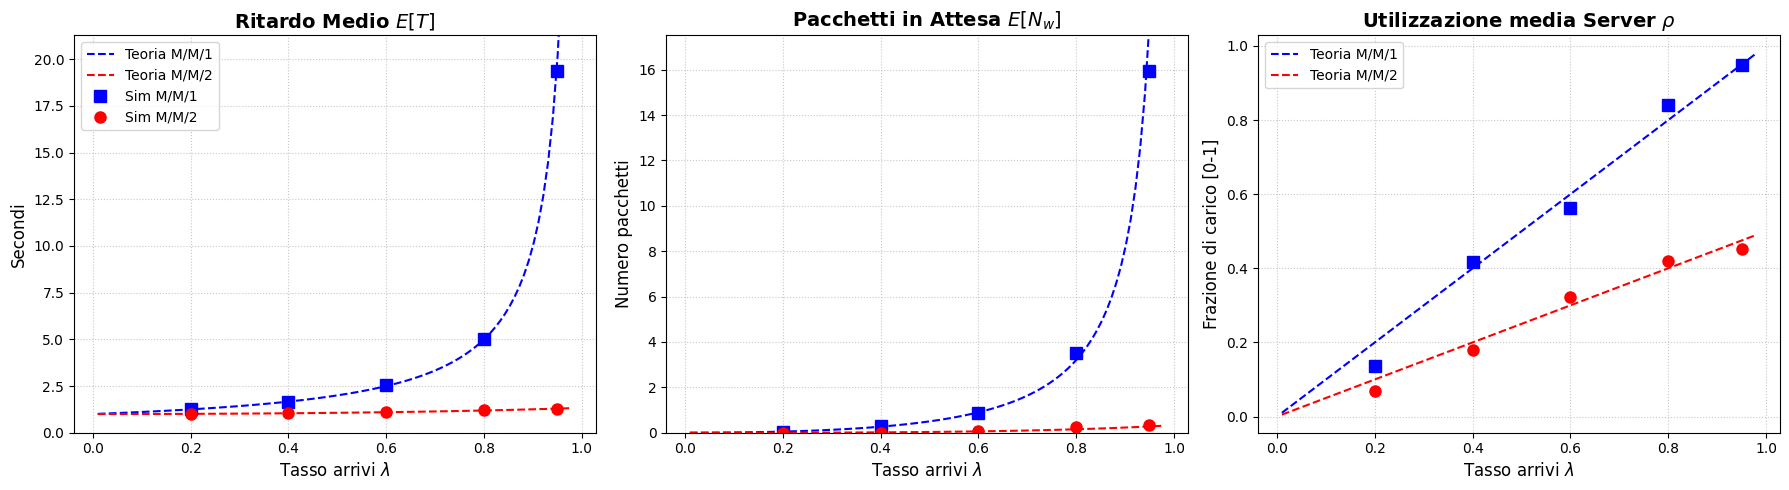

In [76]:
# --- PLOT DELLA DASHBOARD A TRE PANNELLI ---
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# Vettori continui per le curve teoriche perfette
lmb_smooth = np.linspace(0.01, 0.98, 100)

# Calcolo Teorico usando la nuova scatola nera universale!
teoria_d1, teoria_q1, teoria_u1 = [], [], []
teoria_d2, teoria_q2, teoria_u2 = [], [], []

for l in lmb_smooth:
    # Teoria per M/M/1
    t_d1, t_q1, _ = compute_theoretical_metrics(l, MU_BASE, servers=1)
    teoria_d1.append(t_d1)
    teoria_q1.append(t_q1)
    teoria_u1.append(l / MU_BASE)
    
    # Teoria per M/M/2
    t_d2, t_q2, _ = compute_theoretical_metrics(l, MU_BASE, servers=2)
    teoria_d2.append(t_d2)
    teoria_q2.append(t_q2)
    teoria_u2.append(l / (2.0 * MU_BASE))

# 1. GRAFICO RITARDO
ax1.plot(lmb_smooth, teoria_d1, color='blue', linestyle='--', label='Teoria M/M/1')
ax1.plot(lmb_smooth, teoria_d2, color='red', linestyle='--', label='Teoria M/M/2')
ax1.plot(lambdas_comp, delay_1, 's', color='blue', markersize=8, label='Sim M/M/1')
ax1.plot(lambdas_comp, delay_2, 'o', color='red', markersize=8, label='Sim M/M/2')
ax1.set_title("Ritardo Medio $E[T]$", fontsize=14, fontweight='bold')
ax1.set_xlabel("Tasso arrivi $\lambda$", fontsize=12)
ax1.set_ylabel("Secondi", fontsize=12)
ax1.set_ylim(0, max(delay_1)*1.1)
ax1.grid(True, linestyle=':', alpha=0.7)
ax1.legend()

# 2. GRAFICO CODA
ax2.plot(lmb_smooth, teoria_q1, color='blue', linestyle='--', label='Teoria M/M/1')
ax2.plot(lmb_smooth, teoria_q2, color='red', linestyle='--', label='Teoria M/M/2')
ax2.plot(lambdas_comp, queue_1, 's', color='blue', markersize=8)
ax2.plot(lambdas_comp, queue_2, 'o', color='red', markersize=8)
ax2.set_title("Pacchetti in Attesa $E[N_w]$", fontsize=14, fontweight='bold')
ax2.set_xlabel("Tasso arrivi $\lambda$", fontsize=12)
ax2.set_ylabel("Numero pacchetti", fontsize=12)
ax2.set_ylim(0, max(queue_1)*1.1)
ax2.grid(True, linestyle=':', alpha=0.7)

# 3. GRAFICO UTILIZZAZIONE
ax3.plot(lmb_smooth, teoria_u1, color='blue', linestyle='--', label='Teoria M/M/1')
ax3.plot(lmb_smooth, teoria_u2, color='red', linestyle='--', label='Teoria M/M/2')
ax3.plot(lambdas_comp, util_1, 's', color='blue', markersize=8)
ax3.plot(lambdas_comp, util_2, 'o', color='red', markersize=8)
ax3.set_title("Utilizzazione media Server $\\rho$", fontsize=14, fontweight='bold')
ax3.set_xlabel("Tasso arrivi $\lambda$", fontsize=12)
ax3.set_ylabel("Frazione di carico [0-1]", fontsize=12)
ax3.grid(True, linestyle=':', alpha=0.7)
ax3.legend()

plt.tight_layout()
plt.show()

## .b

In [77]:
NUM_SERVERS = 2
MU_RATE = 1.0 # Capacità totale = 2.0

# Spingiamo la rete oltre il limite teorico (Rho > 1) per vedere le perdite!
lambdas_k = [0.4, 0.8, 1.2, 1.6, 2.0, 2.4]

# Le dimensioni del buffer da testare (K)
buffer_sizes = [5, 15, 50, float('inf')]

results_delay = {k: [] for k in buffer_sizes}
results_loss = {k: [] for k in buffer_sizes}

In [78]:
print("="*60)
print(" TASK 2(b): ANALISI MULTI-SERVER CON BUFFER FINITI (M/M/2/K) ")
print("="*60)

for K in buffer_sizes:
    print(f"\n---> Avvio campagna per Buffer K = {K} <---")
    
    for lmb in lambdas_k:
        rho = lmb / (NUM_SERVERS * MU_RATE)
        
        # Evitiamo di simulare il buffer infinito in sovraccarico (esploderebbe la RAM!)
        if K == float('inf') and rho >= 0.95:
            results_delay[K].append(float('nan'))
            results_loss[K].append(float('nan'))
            continue
            
        print(f"Simulazione: Lambda = {lmb} (Rho = {rho:.2f})")
        
        # In sovraccarico con buffer piccoli si va a regime subito, bastano meno pacchetti
        packets_totali = 3000 if K != float('inf') else int(2000 + (25000 * (rho**4)))
        safe_time_limit = (packets_totali / lmb) * 1.5 
        
        # Motore universale (restituisce 6 variabili!)
        _, _, _, avg_d, all_d, avg_loss = run_multiple_sims_router(
            num_runs=15, packets_to_complete=packets_totali, time_limit=safe_time_limit, 
            lambda_rate=lmb, mu_rate=MU_RATE, num_servers=NUM_SERVERS, K=K
        )
        
        # Taglio transitorio dinamico
        k_star_dinamico = 200 if rho < 1.0 else 50
        mean_d, _, _ = perform_statistical_analysis(all_d, k_star=k_star_dinamico, confidence=0.95)
        
        results_delay[K].append(mean_d)
        results_loss[K].append(avg_loss)

 TASK 2(b): ANALISI MULTI-SERVER CON BUFFER FINITI (M/M/2/K) 

---> Avvio campagna per Buffer K = 5 <---
Simulazione: Lambda = 0.4 (Rho = 0.20)
Statistica: N=15 repliche. Applicata distribuzione t di Student.
Simulazione: Lambda = 0.8 (Rho = 0.40)
Statistica: N=15 repliche. Applicata distribuzione t di Student.
Simulazione: Lambda = 1.2 (Rho = 0.60)
Statistica: N=15 repliche. Applicata distribuzione t di Student.
Simulazione: Lambda = 1.6 (Rho = 0.80)
Statistica: N=15 repliche. Applicata distribuzione t di Student.
Simulazione: Lambda = 2.0 (Rho = 1.00)
Statistica: N=15 repliche. Applicata distribuzione t di Student.
Simulazione: Lambda = 2.4 (Rho = 1.20)
Statistica: N=15 repliche. Applicata distribuzione t di Student.

---> Avvio campagna per Buffer K = 15 <---
Simulazione: Lambda = 0.4 (Rho = 0.20)
Statistica: N=15 repliche. Applicata distribuzione t di Student.
Simulazione: Lambda = 0.8 (Rho = 0.40)
Statistica: N=15 repliche. Applicata distribuzione t di Student.
Simulazione: Lambda

<>:36: SyntaxWarning: invalid escape sequence '\l'
<>:44: SyntaxWarning: invalid escape sequence '\l'
<>:36: SyntaxWarning: invalid escape sequence '\l'
<>:44: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_4337/4115418800.py:36: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_xlabel("Tasso arrivi $\lambda$", fontsize=12)
/tmp/ipykernel_4337/4115418800.py:44: SyntaxWarning: invalid escape sequence '\l'
  ax2.set_xlabel("Tasso arrivi $\lambda$", fontsize=12)


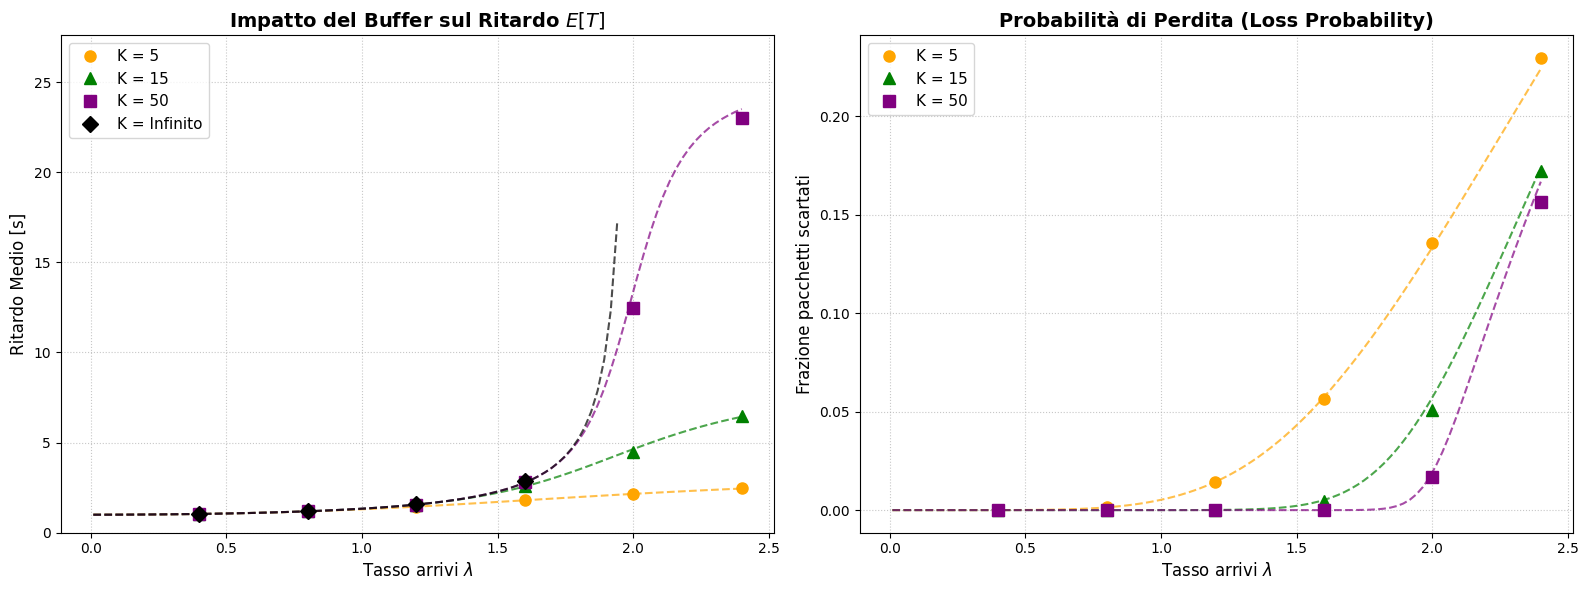

In [79]:
# --- PLOT DEL TRADE-OFF (RITARDO VS PERDITA) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

lmb_smooth = np.linspace(0.01, max(lambdas_k), 100)
colors = {5: 'orange', 15: 'green', 50: 'purple', float('inf'): 'black'}
markers = {5: 'o', 15: '^', 50: 's', float('inf'): 'D'}

for K in buffer_sizes:
    label_k = f"K = {K}" if K != float('inf') else "K = Infinito"
    
    # Teoria Universale
    teoria_delay, teoria_loss = [], []
    for l in lmb_smooth:
        # Se buffer infinito ed esplode, mettiamo NaN per il plot
        if K == float('inf') and l >= (NUM_SERVERS * MU_RATE * 0.98):
            teoria_delay.append(float('nan'))
            teoria_loss.append(0.0)
        else:
            t_d, _, t_l = compute_theoretical_metrics(l, MU_RATE, servers=NUM_SERVERS, buffer_size=K)
            teoria_delay.append(t_d)
            teoria_loss.append(t_l)
            
    # Grafico 1: RITARDO
    ax1.plot(lmb_smooth, teoria_delay, color=colors[K], linestyle='--', alpha=0.7)
    ax1.plot(lambdas_k, results_delay[K], marker=markers[K], color=colors[K], 
             linestyle='None', markersize=8, label=label_k)
             
    # Grafico 2: LOSS (Non lo tracciamo per l'infinito perché è una linea piatta a 0)
    if K != float('inf'):
        ax2.plot(lmb_smooth, teoria_loss, color=colors[K], linestyle='--', alpha=0.7)
        ax2.plot(lambdas_k, results_loss[K], marker=markers[K], color=colors[K], 
                 linestyle='None', markersize=8, label=label_k)

# Formattazione Grafico 1: RITARDO
ax1.set_title("Impatto del Buffer sul Ritardo $E[T]$", fontsize=14, fontweight='bold')
ax1.set_xlabel("Tasso arrivi $\lambda$", fontsize=12)
ax1.set_ylabel("Ritardo Medio [s]", fontsize=12)
ax1.set_ylim(0, max([x for x in results_delay[50] if not math.isnan(x)]) * 1.2) # Auto-zoom
ax1.grid(True, linestyle=':', alpha=0.7)
ax1.legend(fontsize=11)

# Formattazione Grafico 2: LOSS
ax2.set_title("Probabilità di Perdita (Loss Probability)", fontsize=14, fontweight='bold')
ax2.set_xlabel("Tasso arrivi $\lambda$", fontsize=12)
ax2.set_ylabel("Frazione pacchetti scartati", fontsize=12)
ax2.grid(True, linestyle=':', alpha=0.7)
ax2.legend(fontsize=11)

plt.tight_layout()
plt.show()

## .c

In [80]:
MU_RATE = 1.0
K_TOTALE = 20
K_SEPARATO = int(K_TOTALE / 2) # 10 slot per ogni singola coda

# Testiamo fino all'Heavy Traffic puro (Rho = 1.2) per vedere chi "droppa" di meno
lambdas_sfida = [0.4, 0.8, 1.2, 1.6, 2.0, 2.4]

delay_shared, loss_shared = [], []
delay_sep, loss_sep = [], []

In [81]:
print("="*60)
print(f" TASK 2(c): SFIDA ARCHITETTURALE (Buffer Totale = {K_TOTALE}) ")
print("="*60)

for lmb in lambdas_sfida:
    print(f"Simulazione Lambda = {lmb} in corso...")
    
    packets_totali = 4000
    safe_time_limit = (packets_totali / lmb) * 1.5 
    k_star_dinamico = 200 # Con buffer piccoli va a regime presto
    
    # ---------------------------------------------------------
    # 1. SISTEMA CONDIVISO (M/M/2/K)
    # Usa il simulatore originale a 6 uscite
    # ---------------------------------------------------------
    _, _, _, _, all_d_shared, avg_loss_sh = run_multiple_sims_router(
        num_runs=15, packets_to_complete=packets_totali, time_limit=safe_time_limit, 
        lambda_rate=lmb, mu_rate=MU_RATE, num_servers=2, K=K_TOTALE
    )
    mean_d_sh, _, _ = perform_statistical_analysis(all_d_shared, k_star=k_star_dinamico, confidence=0.95)
    delay_shared.append(mean_d_sh)
    loss_shared.append(avg_loss_sh)
    
    # ---------------------------------------------------------
    # 2. SISTEMA SEPARATO (JSQ + classe Measure)
    # Attenzione all'unpacking: ora ha 5 uscite!
    # ---------------------------------------------------------
    avg_q_sep, avg_sys_sep, _, all_d_sep, avg_loss_sep = run_multiple_jsq_generic(
        num_runs=15, packets_to_complete=packets_totali, 
        lambda_rate=lmb, mu_rate=MU_RATE, num_servers=2, K_per_queue=K_SEPARATO
    )
    mean_d_sep, _, _ = perform_statistical_analysis(all_d_sep, k_star=k_star_dinamico, confidence=0.95)
    delay_sep.append(mean_d_sep)
    loss_sep.append(avg_loss_sep)

 TASK 2(c): SFIDA ARCHITETTURALE (Buffer Totale = 20) 
Simulazione Lambda = 0.4 in corso...
Statistica: N=15 repliche. Applicata distribuzione t di Student.
Statistica: N=15 repliche. Applicata distribuzione t di Student.
Simulazione Lambda = 0.8 in corso...
Statistica: N=15 repliche. Applicata distribuzione t di Student.
Statistica: N=15 repliche. Applicata distribuzione t di Student.
Simulazione Lambda = 1.2 in corso...
Statistica: N=15 repliche. Applicata distribuzione t di Student.
Statistica: N=15 repliche. Applicata distribuzione t di Student.
Simulazione Lambda = 1.6 in corso...
Statistica: N=15 repliche. Applicata distribuzione t di Student.
Statistica: N=15 repliche. Applicata distribuzione t di Student.
Simulazione Lambda = 2.0 in corso...
Statistica: N=15 repliche. Applicata distribuzione t di Student.
Statistica: N=15 repliche. Applicata distribuzione t di Student.
Simulazione Lambda = 2.4 in corso...
Statistica: N=15 repliche. Applicata distribuzione t di Student.
Statisti

<>:8: SyntaxWarning: invalid escape sequence '\l'
<>:17: SyntaxWarning: invalid escape sequence '\l'
<>:8: SyntaxWarning: invalid escape sequence '\l'
<>:17: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_4337/2109821324.py:8: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_xlabel("Tasso arrivi $\lambda$", fontsize=12)
/tmp/ipykernel_4337/2109821324.py:17: SyntaxWarning: invalid escape sequence '\l'
  ax2.set_xlabel("Tasso arrivi $\lambda$", fontsize=12)


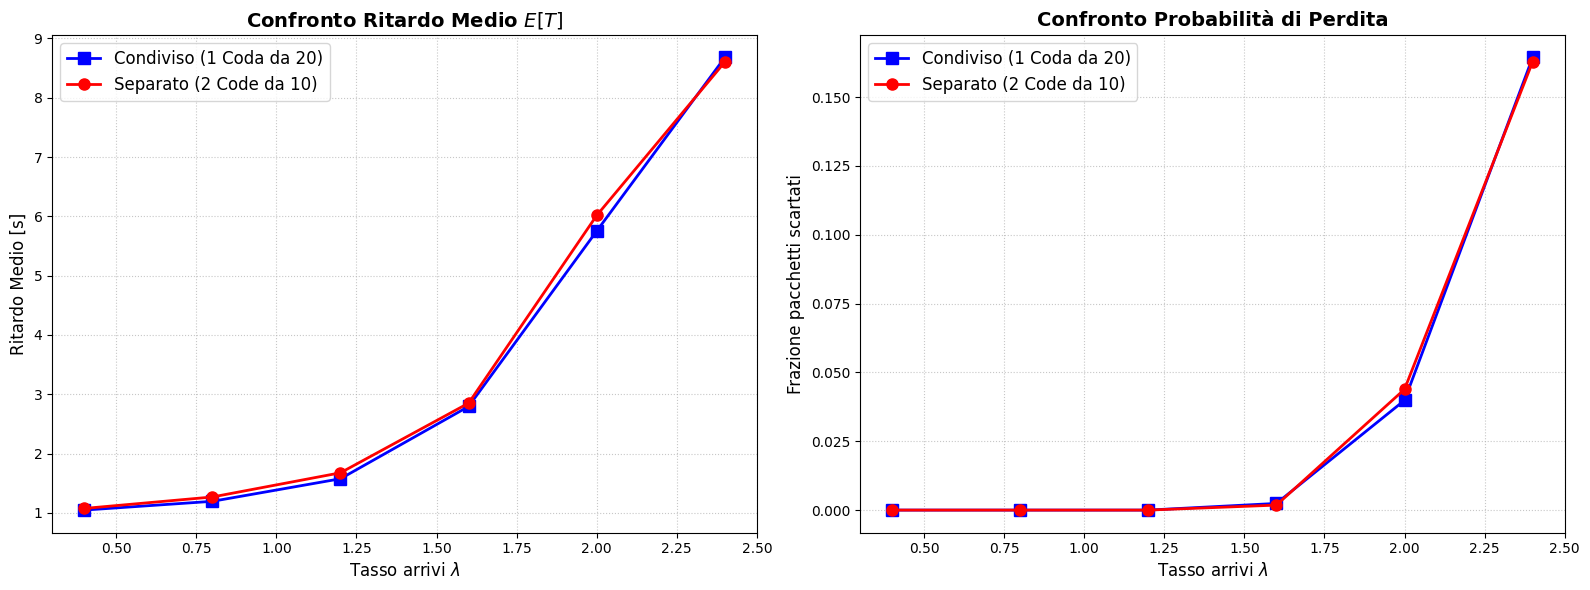

In [82]:
# --- PLOT DEL CONFRONTO FINALE ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Grafico 1: RITARDO
ax1.plot(lambdas_sfida, delay_shared, marker='s', color='blue', linestyle='-', linewidth=2, markersize=8, label=f'Condiviso (1 Coda da {K_TOTALE})')
ax1.plot(lambdas_sfida, delay_sep, marker='o', color='red', linestyle='-', linewidth=2, markersize=8, label=f'Separato (2 Code da {K_SEPARATO})')
ax1.set_title("Confronto Ritardo Medio $E[T]$", fontsize=14, fontweight='bold')
ax1.set_xlabel("Tasso arrivi $\lambda$", fontsize=12)
ax1.set_ylabel("Ritardo Medio [s]", fontsize=12)
ax1.grid(True, linestyle=':', alpha=0.7)
ax1.legend(fontsize=12)

# Grafico 2: LOSS PROBABILITY
ax2.plot(lambdas_sfida, loss_shared, marker='s', color='blue', linestyle='-', linewidth=2, markersize=8, label=f'Condiviso (1 Coda da {K_TOTALE})')
ax2.plot(lambdas_sfida, loss_sep, marker='o', color='red', linestyle='-', linewidth=2, markersize=8, label=f'Separato (2 Code da {K_SEPARATO})')
ax2.set_title("Confronto Probabilità di Perdita", fontsize=14, fontweight='bold')
ax2.set_xlabel("Tasso arrivi $\lambda$", fontsize=12)
ax2.set_ylabel("Frazione pacchetti scartati", fontsize=12)
ax2.grid(True, linestyle=':', alpha=0.7)
ax2.legend(fontsize=12)

plt.tight_layout()
plt.show()